# Music Recommendation System: Data Preparation Pipeline
This notebook handles the end-to-end data processing from raw Spotify CSV exports to ML-ready transition pairs.

## Phase 1: CSV Playlist Processing
Collects raw CSVs, adds metadata, and creates a `master_dataset.csv`.

In [1]:
import pandas as pd
import os

# Define base directory paths
raw_playlists_dir = '../data/raw_playlists'
processed_dir = '../data/processed'

if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)
    print(f"Created directory: {processed_dir}")

In [2]:
all_dfs = []
global_pid_counter = 1

regions = [d for d in os.listdir(raw_playlists_dir) if os.path.isdir(os.path.join(raw_playlists_dir, d))]

for region in regions:
    region_path = os.path.join(raw_playlists_dir, region)
    genres = sorted([d for d in os.listdir(region_path) if os.path.isdir(os.path.join(region_path, d))])
    
    for genre in genres:
        genre_path = os.path.join(region_path, genre)
        csv_files = sorted([f for f in os.listdir(genre_path) if f.endswith('.csv')])
        
        for filename in csv_files:
            file_path = os.path.join(genre_path, filename)
            try:
                df = pd.read_csv(file_path)
                df = df.dropna(how='all')
                df['region_genre_id'] = f"{region}_{genre}"
                df['pid'] = global_pid_counter
                df['original_filename'] = filename
                
                all_dfs.append(df)
                global_pid_counter += 1
            except Exception as e:
                print(f"Error processing {filename}: {e}")

In [3]:
if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)
    master_df.to_csv(os.path.join(processed_dir, 'master_dataset.csv'), index=False)
    print(f"Master Dataset: {master_df['pid'].nunique()} playlists, {len(master_df)} tracks.")
else:
    print("No data found.")

Master Dataset: 29 playlists, 3813 tracks.


## Phase 2: Data Cleaning & Preprocessing
Ensures data integrity, performs positioning (1-based), and generates `clean_dataset.csv`.

In [4]:
# 1. Select relevant columns
required_columns = [
    'Track URI', 'Track Name', 'Artist Name(s)',
    'Danceability', 'Energy', 'Key', 'Loudness', 'Mode',
    'Speechiness', 'Acousticness', 'Instrumentalness',
    'Liveness', 'Valence', 'Tempo',
    'pid', 'region_genre_id'
]
df_processing = master_df[required_columns].copy()

# 2. ID Extraction
df_processing['track_id'] = df_processing['Track URI'].str.split(':').str[-1]

# 3. CLEANING FIRST (Drop NaNs and Duplicates within PID)
df_processing = df_processing.dropna()
df_processing = df_processing.drop_duplicates(subset=['track_id', 'pid'])

# 4. POSITIONING SECOND (1-based index per playlist)
df_processing['position'] = df_processing.groupby('pid').cumcount() + 1
df_processing['pid_position'] = df_processing['pid'].astype(str) + "_" + df_processing['position'].astype(str)

# 5. Final Sort & Save
df_clean = df_processing.sort_values(by=['pid', 'position'])
df_clean.to_csv(os.path.join(processed_dir, 'clean_dataset.csv'), index=False)
print(f"Clean Dataset: {df_clean['pid'].nunique()} playlists, {len(df_clean)} unique tracks.")

Clean Dataset: 29 playlists, 3576 unique tracks.


In [4]:
  import os
  import random
  import numpy as np
  import pandas as pd

  from sklearn.model_selection import train_test_split
  from sklearn.metrics import roc_auc_score, classification_report

  RANDOM_STATE = 42
  random.seed(RANDOM_STATE)
  np.random.seed(RANDOM_STATE)

  processed_dir = "../data/processed"
  clean_path = os.path.join(processed_dir, "clean_dataset.csv")

  df_clean = pd.read_csv(clean_path)
  df_clean = df_clean.sort_values(["pid", "position"]).reset_index(drop=True)

  print("Rows:", len(df_clean))
  print("Playlists:", df_clean["pid"].nunique())
  df_clean.head()

Rows: 3576
Playlists: 29


,Track URI,Track Name,Artist Name(s),Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,pid,region_genre_id,track_id,position,pid_position
0,spotify:track:7vZz8oJ5qAqB9MghufRK5k,Zinda,Shankar-Ehsaan-Loy;Siddharth Mahadevan,0.603,0.708,4.0,-7.047,0.0,0.0379,0.000173,0.000003,0.1580,0.611,105.046,1,hindi_chill_lyrics,7vZz8oJ5qAqB9MghufRK5k,1,1_1
1,spotify:track:3kSBSSsXtebECjCggW87yq,Sultan,Vishal-Shekhar;Sukhwinder Singh;Shadab Faridi;...,0.669,0.866,2.0,-6.628,1.0,0.0499,0.058900,0.000000,0.0463,0.288,119.992,1,hindi_chill_lyrics,3kSBSSsXtebECjCggW87yq,2,1_2
2,spotify:track:7EpZ8kdKyQM4GMJy2tj0We,Dangal,Daler Mehndi,0.618,0.867,6.0,-5.100,0.0,0.1390,0.239000,0.000000,0.0559,0.665,178.017,1,hindi_chill_lyrics,7EpZ8kdKyQM4GMJy2tj0We,3,1_3
3,spotify:track:3FHl1QYu76zguwjqhqcglX,"Kar Har Maidaan Fateh (From ""Sanju"")",Sukhwinder Singh;Shreya Ghoshal;Vikram Montrose,0.557,0.821,1.0,-7.794,0.0,0.0573,0.018900,0.000000,0.0863,0.184,170.022,1,hindi_chill_lyrics,3FHl1QYu76zguwjqhqcglX,4,1_4
4,spotify:track:3uZiNvBNQldjl4OJiKsuxe,Brothers Anthem,Ajay-Atul;Vishal Dadlani,0.552,0.668,2.0,-9.111,1.0,0.0473,0.421000,0.011700,0.1590,0.152,95.032,1,hindi_chill_lyrics,3uZiNvBNQldjl4OJiKsuxe,5,1_5


In [5]:
  song_cols = [
      "track_id", "Track Name", "Artist Name(s)",
      "Danceability", "Energy", "Key", "Loudness", "Mode",
      "Speechiness", "Acousticness", "Instrumentalness",
      "Liveness", "Valence", "Tempo"
  ]

  context_cols = ["pid", "region_genre_id", "position", "pid_position"]

  next_df = df_clean.groupby("pid")[song_cols + context_cols].shift(-1)

  positive_pairs = pd.concat([
      df_clean[song_cols + context_cols].add_prefix("source_"),
      next_df.add_prefix("target_")
  ], axis=1)

  positive_pairs = positive_pairs.dropna(subset=["target_track_id"]).copy()
  positive_pairs["label"] = 1

  print("Positive pairs:", len(positive_pairs))

  display(
      positive_pairs[
          [
              "label",
              "source_pid",
              "source_region_genre_id",
              "source_position",
              "source_pid_position",
              "source_track_id",
              "source_Track Name",
              "target_pid",
              "target_region_genre_id",
              "target_position",
              "target_pid_position",
              "target_track_id",
              "target_Track Name",
          ]
      ].head(15)
  )

Positive pairs: 3547


,label,source_pid,source_region_genre_id,source_position,source_pid_position,source_track_id,source_Track Name,target_pid,target_region_genre_id,target_position,target_pid_position,target_track_id,target_Track Name
0,1,1,hindi_chill_lyrics,1,1_1,7vZz8oJ5qAqB9MghufRK5k,Zinda,1.0,hindi_chill_lyrics,2.0,1_2,3kSBSSsXtebECjCggW87yq,Sultan
1,1,1,hindi_chill_lyrics,2,1_2,3kSBSSsXtebECjCggW87yq,Sultan,1.0,hindi_chill_lyrics,3.0,1_3,7EpZ8kdKyQM4GMJy2tj0We,Dangal
2,1,1,hindi_chill_lyrics,3,1_3,7EpZ8kdKyQM4GMJy2tj0We,Dangal,1.0,hindi_chill_lyrics,4.0,1_4,3FHl1QYu76zguwjqhqcglX,"Kar Har Maidaan Fateh (From ""Sanju"")"
3,1,1,hindi_chill_lyrics,4,1_4,3FHl1QYu76zguwjqhqcglX,"Kar Har Maidaan Fateh (From ""Sanju"")",1.0,hindi_chill_lyrics,5.0,1_5,3uZiNvBNQldjl4OJiKsuxe,Brothers Anthem
4,1,1,hindi_chill_lyrics,5,1_5,3uZiNvBNQldjl4OJiKsuxe,Brothers Anthem,1.0,hindi_chill_lyrics,6.0,1_6,3MxLT7m4BjAA0lQl9lVBcM,Jai Ho
5,1,1,hindi_chill_lyrics,6,1_6,3MxLT7m4BjAA0lQl9lVBcM,Jai Ho,1.0,hindi_chill_lyrics,7.0,1_7,2xYbk2WDq38a0wuRyjT1mE,Jee Karda (Rock Version)
6,1,1,hindi_chill_lyrics,7,1_7,2xYbk2WDq38a0wuRyjT1mE,Jee Karda (Rock Version),1.0,hindi_chill_lyrics,8.0,1_8,7k3jpyYPnVnbO0p7iejWxL,Saadda Haq
7,1,1,hindi_chill_lyrics,8,1_8,7k3jpyYPnVnbO0p7iejWxL,Saadda Haq,1.0,hindi_chill_lyrics,9.0,1_9,01d8tSqJUrPlK1l8FwgsCF,Soorma Anthem
8,1,1,hindi_chill_lyrics,9,1_9,01d8tSqJUrPlK1l8FwgsCF,Soorma Anthem,1.0,hindi_chill_lyrics,10.0,1_10,3pjZQfBShK7O01QvtQwmcg,Raftaarein
9,1,1,hindi_chill_lyrics,10,1_10,3pjZQfBShK7O01QvtQwmcg,Raftaarein,1.0,hindi_chill_lyrics,11.0,1_11,0KtHnXQjYkHNDsjTX3XqLc,Bhaag Milkha Bhaag - Rock Version


In [6]:
# CELL A3: Build negative pairs
# Strategy: for each positive source song, sample random target songs that are NOT from the same playlist

NEGATIVE_RATIO = 2  # 2 negatives per positive

unique_tracks = (
  df_clean.sort_values(["track_id", "pid", "position"])
  .drop_duplicates(subset=["track_id"])
  .reset_index(drop=True)
)

track_feature_cols = [
  "track_id", "Track Name", "Artist Name(s)",
  "Danceability", "Energy", "Key", "Loudness", "Mode",
  "Speechiness", "Acousticness", "Instrumentalness",
  "Liveness", "Valence", "Tempo"
]

track_lookup = unique_tracks[track_feature_cols].set_index("track_id").to_dict("index")
all_track_ids = unique_tracks["track_id"].tolist()

playlist_track_sets = df_clean.groupby("pid")["track_id"].apply(set).to_dict()

negative_rows = []

for _, row in positive_pairs.iterrows():
  source_pid = row["source_pid"]
  source_playlist_tracks = playlist_track_sets[source_pid]
  source_track_id = row["source_track_id"]

  valid_targets = [
      tid for tid in all_track_ids
      if tid not in source_playlist_tracks and tid != source_track_id
  ]

  if len(valid_targets) == 0:
      continue

  sampled_targets = random.sample(valid_targets, k=min(NEGATIVE_RATIO, len(valid_targets)))

  for target_tid in sampled_targets:
      target_song = track_lookup[target_tid]

      negative_rows.append({
          "source_pid": row["source_pid"],
          "source_region_genre_id": row["source_region_genre_id"],
          "source_position": row["source_position"],
          "source_pid_position": row["source_pid_position"],
          "source_track_id": row["source_track_id"],
          "source_Track Name": row["source_Track Name"],
          "source_Artist Name(s)": row["source_Artist Name(s)"],
          "source_Danceability": row["source_Danceability"],
          "source_Energy": row["source_Energy"],
          "source_Key": row["source_Key"],
          "source_Loudness": row["source_Loudness"],
          "source_Mode": row["source_Mode"],
          "source_Speechiness": row["source_Speechiness"],
          "source_Acousticness": row["source_Acousticness"],
          "source_Instrumentalness": row["source_Instrumentalness"],
          "source_Liveness": row["source_Liveness"],
          "source_Valence": row["source_Valence"],
          "source_Tempo": row["source_Tempo"],

          "target_pid": np.nan,
          "target_region_genre_id": np.nan,
          "target_position": np.nan,
          "target_pid_position": np.nan,
          "target_track_id": target_tid,
          "target_Track Name": target_song["Track Name"],
          "target_Artist Name(s)": target_song["Artist Name(s)"],
          "target_Danceability": target_song["Danceability"],
          "target_Energy": target_song["Energy"],
          "target_Key": target_song["Key"],
          "target_Loudness": target_song["Loudness"],
          "target_Mode": target_song["Mode"],
          "target_Speechiness": target_song["Speechiness"],
          "target_Acousticness": target_song["Acousticness"],
          "target_Instrumentalness": target_song["Instrumentalness"],
          "target_Liveness": target_song["Liveness"],
          "target_Valence": target_song["Valence"],
          "target_Tempo": target_song["Tempo"],

          "label": 0
      })

negative_pairs = pd.DataFrame(negative_rows)

print("Negative pairs:", len(negative_pairs))
display(
  negative_pairs[
      [
          "label",
          "source_pid",
          "source_pid_position",
          "source_track_id",
          "source_Track Name",
          "target_track_id",
          "target_Track Name"
      ]
  ].head(15)
)

Negative pairs: 7094


,label,source_pid,source_pid_position,source_track_id,source_Track Name,target_track_id,target_Track Name
0,0,1,1_1,7vZz8oJ5qAqB9MghufRK5k,Zinda,7Au8Kxz2LoqWR638zABC5d,Ekkada Ekkada
1,0,1,1_1,7vZz8oJ5qAqB9MghufRK5k,Zinda,1CsRoIeHaHRysPMoEaKRoQ,Tum Mile - Lofi Flip
2,0,1,1_2,3kSBSSsXtebECjCggW87yq,Sultan,0GQngE2rOYvlKwEQjTAsP8,Subhanallah
3,0,1,1_2,3kSBSSsXtebECjCggW87yq,Sultan,38YurGQv1nG2dgVPMiCx5X,Tonight
4,0,1,1_3,7EpZ8kdKyQM4GMJy2tj0We,Dangal,2kbOQ5mwZSig2jfJwLfDE0,528 Hz Let Go of Overthinking & Worries
5,0,1,1_3,7EpZ8kdKyQM4GMJy2tj0We,Dangal,2XwSFpqaP09dCKRsXK7a4J,Cream
6,0,1,1_4,3FHl1QYu76zguwjqhqcglX,"Kar Har Maidaan Fateh (From ""Sanju"")",1b2nrwUSqVPuamGbTRKIkw,Moonlight Sonata: Beethoven Reimagined - Felt ...
7,0,1,1_4,3FHl1QYu76zguwjqhqcglX,"Kar Har Maidaan Fateh (From ""Sanju"")",17XNFLFmolqojlFDPuxjHx,In the Echoes
8,0,1,1_5,3uZiNvBNQldjl4OJiKsuxe,Brothers Anthem,7lvDsmTRXFE3dK4OjvRiWB,Pasoori
9,0,1,1_5,3uZiNvBNQldjl4OJiKsuxe,Brothers Anthem,68HvRKLpQNKsLCe0PwlvMH,To The Moon


In [7]:

  # CELL A4: Combine and save labeled pair dataset

  positive_export = positive_pairs.copy()

  labeled_pairs = pd.concat(
      [positive_export, negative_pairs],
      ignore_index=True
  ).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

  pairs_path = os.path.join(processed_dir, "phase1_labeled_pairs.csv")
  labeled_pairs.to_csv(pairs_path, index=False)

  print("Saved:", pairs_path)
  print(labeled_pairs["label"].value_counts())
  print(labeled_pairs[["label", "source_track_id", "target_track_id"]].head())



Saved: ../data/processed\phase1_labeled_pairs.csv
label
0    7094
1    3547
Name: count, dtype: int64
   label         source_track_id         target_track_id
0      1  0UtamWoSO1E5UFcfrDNBli  000PqTyXjCLX8OF0VFASGs
1      1  6d77EgzJQqzb3NX9MjrTww  3rgTS3933lMWoPiN6CW4qY
2      0  582t08OyJrrpS35HyWSruM  7qzgHrqG8FgzgPIfBE23Bw
3      1  4HfN7246HT9BiXgU0d5HLl  4EGilW7VYfTULk4RENDfJp
4      1  6AWtSRoOg8ZnGtP9yEig82  4liIcfDaMjgwLymHO0LUXG


In [8]:
# CELL B1: Build Phase 1 feature matrix
# Uses absolute differences for continuous features
# Uses circle-of-fifths distance for Key
# Uses absolute difference for Mode

continuous_features = [
  "Danceability", "Energy", "Loudness", "Speechiness",
  "Acousticness", "Instrumentalness", "Liveness",
  "Valence", "Tempo"
]

circle_of_fifths_order = [0, 7, 2, 9, 4, 11, 6, 1, 8, 3, 10, 5]
fifths_pos = {k: i for i, k in enumerate(circle_of_fifths_order)}

def circle_of_fifths_distance(k1, k2):
  k1 = int(k1)
  k2 = int(k2)
  p1 = fifths_pos[k1]
  p2 = fifths_pos[k2]
  diff = abs(p1 - p2)
  return min(diff, 12 - diff) / 6.0  # normalized to [0, 1]

phase1_df = labeled_pairs.copy()

for feat in continuous_features:
  phase1_df[f"diff_{feat.lower()}"] = (
      phase1_df[f"source_{feat}"] - phase1_df[f"target_{feat}"]
  ).abs()

phase1_df["diff_mode"] = (
  phase1_df["source_Mode"] - phase1_df["target_Mode"]
).abs()

phase1_df["diff_key_fifths"] = phase1_df.apply(
  lambda r: circle_of_fifths_distance(r["source_Key"], r["target_Key"]),
  axis=1
)

phase1_feature_cols = [
  "diff_danceability",
  "diff_energy",
  "diff_loudness",
  "diff_speechiness",
  "diff_acousticness",
  "diff_instrumentalness",
  "diff_liveness",
  "diff_valence",
  "diff_tempo",
  "diff_mode",
  "diff_key_fifths"
]

X = phase1_df[phase1_feature_cols]
y = phase1_df["label"]

feature_matrix_path = os.path.join(processed_dir, "phase1_feature_matrix.csv")
phase1_df[phase1_feature_cols + ["label"]].to_csv(feature_matrix_path, index=False)

print("Saved:", feature_matrix_path)
print("Shape:", X.shape)
X.head()

Saved: ../data/processed\phase1_feature_matrix.csv
Shape: (10641, 11)


,diff_danceability,diff_energy,diff_loudness,diff_speechiness,diff_acousticness,diff_instrumentalness,diff_liveness,diff_valence,diff_tempo,diff_mode,diff_key_fifths
0,0.247,0.3630,4.157,0.0548,0.51500,0.328784,0.0318,0.4430,3.052,0.0,1.000000
1,0.086,0.0700,2.117,0.0720,0.17930,0.044740,0.4382,0.0230,2.009,1.0,0.833333
2,0.006,0.5820,4.639,0.0127,0.58820,0.000048,0.0290,0.4660,27.845,1.0,0.500000
3,0.179,0.5290,6.374,0.0149,0.28586,0.719000,0.0760,0.5410,2.907,1.0,0.333333
4,0.042,0.0451,0.701,0.0006,0.04400,0.104000,0.0050,0.0001,63.439,0.0,0.166667


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=RANDOM_STATE,
  stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

Train shape: (8512, 11)
Test shape: (2129, 11)
Train label distribution:
label
0    0.666706
1    0.333294
Name: proportion, dtype: float64


In [10]:
# CELL B3: Train XGBoost Phase 1 model

try:
  from xgboost import XGBClassifier
except ImportError:
  raise ImportError(
      "xgboost is not installed. Run this in a notebook cell first:\n\n%pip install xgboost"
  )

phase1_model = XGBClassifier(
  n_estimators=300,
  max_depth=5,
  learning_rate=0.05,
  subsample=0.9,
  colsample_bytree=0.9,
  objective="binary:logistic",
  eval_metric="auc",
  random_state=RANDOM_STATE
)

phase1_model.fit(X_train, y_train)

y_proba = phase1_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)

print("Phase 1 ROC-AUC:", round(auc, 4))
print()
print(classification_report(y_test, y_pred, digits=4))

Phase 1 ROC-AUC: 0.8981

              precision    recall  f1-score   support

           0     0.8738    0.8492    0.8613      1419
           1     0.7147    0.7549    0.7342       710

    accuracy                         0.8178      2129
   macro avg     0.7942    0.8021    0.7978      2129
weighted avg     0.8207    0.8178    0.8189      2129



In [11]:
# CELL C1: Threshold sweep on the current baseline model
# Why:
# ROC-AUC is good, but classification at threshold=0.5 may not be optimal.
# This cell shows how precision/recall for class 1 changes across thresholds.

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

threshold_rows = []

for thr in np.arange(0.10, 0.91, 0.05):
  pred_thr = (y_proba >= thr).astype(int)
  threshold_rows.append({
      "threshold": round(float(thr), 2),
      "precision_class_1": precision_score(y_test, pred_thr, pos_label=1, zero_division=0),
      "recall_class_1": recall_score(y_test, pred_thr, pos_label=1, zero_division=0),
      "f1_class_1": f1_score(y_test, pred_thr, pos_label=1, zero_division=0),
  })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.sort_values("f1_class_1", ascending=False).head(10))

,threshold,precision_class_1,recall_class_1,f1_class_1
7,0.45,0.696067,0.822535,0.754035
5,0.35,0.648073,0.900000,0.753538
6,0.40,0.668484,0.863380,0.753534
4,0.30,0.621777,0.916901,0.741036
8,0.50,0.714667,0.754930,0.734247
3,0.25,0.602180,0.933803,0.732192
2,0.20,0.588133,0.949296,0.726293
1,0.15,0.570248,0.971831,0.718750
0,0.10,0.551181,0.985915,0.707071
9,0.55,0.721362,0.656338,0.687316


In [12]:
# CELL C2: Find useful threshold candidates
# Why:
# We want to know:
# 1. best F1 threshold
# 2. if any threshold gives precision >= 0.80
# 3. if any threshold gives recall >= 0.80

best_f1_row = threshold_df.sort_values("f1_class_1", ascending=False).iloc[0]

print("Best F1 threshold")
display(best_f1_row.to_frame().T)

precision_80 = threshold_df[threshold_df["precision_class_1"] >= 0.80]
recall_80 = threshold_df[threshold_df["recall_class_1"] >= 0.80]

print("Thresholds with precision >= 0.80")
display(precision_80.head(10))

print("Thresholds with recall >= 0.80")
display(recall_80.head(10))

Best F1 threshold


,threshold,precision_class_1,recall_class_1,f1_class_1
7,0.45,0.696067,0.822535,0.754035


Thresholds with precision >= 0.80


,threshold,precision_class_1,recall_class_1,f1_class_1
12,0.70,0.827692,0.378873,0.519807
13,0.75,0.843478,0.273239,0.412766
14,0.80,0.854305,0.181690,0.299652
15,0.85,0.841463,0.097183,0.174242
16,0.90,0.888889,0.045070,0.085791


Thresholds with recall >= 0.80


,threshold,precision_class_1,recall_class_1,f1_class_1
0,0.10,0.551181,0.985915,0.707071
1,0.15,0.570248,0.971831,0.718750
2,0.20,0.588133,0.949296,0.726293
3,0.25,0.602180,0.933803,0.732192
4,0.30,0.621777,0.916901,0.741036
5,0.35,0.648073,0.900000,0.753538
6,0.40,0.668484,0.863380,0.753534
7,0.45,0.696067,0.822535,0.754035


In [13]:
# CELL C3: Retrain Phase 1 with class weighting
# Why:
# Positive class is smaller. scale_pos_weight can reduce the model's bias toward class 0.

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

print("scale_pos_weight:", round(float(spw), 4))

phase1_model_weighted = XGBClassifier(
  n_estimators=300,
  max_depth=5,
  learning_rate=0.05,
  subsample=0.9,
  colsample_bytree=0.9,
  objective="binary:logistic",
  eval_metric="auc",
  random_state=RANDOM_STATE,
  scale_pos_weight=spw
)

phase1_model_weighted.fit(X_train, y_train)

y_proba_weighted = phase1_model_weighted.predict_proba(X_test)[:, 1]
y_pred_weighted = (y_proba_weighted >= 0.5).astype(int)

auc_weighted = roc_auc_score(y_test, y_proba_weighted)

print("Weighted Phase 1 ROC-AUC:", round(auc_weighted, 4))
print()
print(classification_report(y_test, y_pred_weighted, digits=4))

scale_pos_weight: 2.0004
Weighted Phase 1 ROC-AUC: 0.8992

              precision    recall  f1-score   support

           0     0.9301    0.7590    0.8359      1419
           1     0.6478    0.8859    0.7484       710

    accuracy                         0.8013      2129
   macro avg     0.7889    0.8225    0.7921      2129
weighted avg     0.8359    0.8013    0.8067      2129



In [14]:
  # CELL C4: Threshold sweep for the weighted model
  # Why:
  # Class weighting and threshold tuning should be evaluated together.

  threshold_rows_weighted = []

  for thr in np.arange(0.10, 0.91, 0.05):
      pred_thr = (y_proba_weighted >= thr).astype(int)
      threshold_rows_weighted.append({
          "threshold": round(float(thr), 2),
          "precision_class_1": precision_score(y_test, pred_thr, pos_label=1, zero_division=0),
          "recall_class_1": recall_score(y_test, pred_thr, pos_label=1, zero_division=0),
          "f1_class_1": f1_score(y_test, pred_thr, pos_label=1, zero_division=0),
      })

  threshold_df_weighted = pd.DataFrame(threshold_rows_weighted)

In [15]:
# CELL C5: Build harder negatives
# Why:
# Random negatives are often too easy.
# Here, each negative is sampled from the same region_genre_id but not from the same playlist.
# This forces the model to learn finer transition logic.

NEGATIVE_RATIO_HARD = 2

same_group_tracks = (
  df_clean.groupby("region_genre_id")["track_id"]
  .apply(list)
  .to_dict()
)

track_lookup_full = (
  unique_tracks.set_index("track_id")[
      ["Track Name", "Artist Name(s)", "Danceability", "Energy", "Key", "Loudness",
       "Mode", "Speechiness", "Acousticness", "Instrumentalness", "Liveness",
       "Valence", "Tempo"]
  ].to_dict("index")
)

hard_negative_rows = []

for _, row in positive_pairs.iterrows():
  source_pid = row["source_pid"]
  source_group = row["source_region_genre_id"]
  source_track_id = row["source_track_id"]

  same_group_pool = same_group_tracks.get(source_group, [])
  source_playlist_tracks = playlist_track_sets[source_pid]

  valid_targets = [
      tid for tid in same_group_pool
      if tid not in source_playlist_tracks and tid != source_track_id
  ]

  if len(valid_targets) == 0:
      continue

  sampled_targets = random.sample(valid_targets, k=min(NEGATIVE_RATIO_HARD, len(valid_targets)))

  for target_tid in sampled_targets:
      target_song = track_lookup_full[target_tid]

      hard_negative_rows.append({
          "source_pid": row["source_pid"],
          "source_region_genre_id": row["source_region_genre_id"],
          "source_position": row["source_position"],
          "source_pid_position": row["source_pid_position"],
          "source_track_id": row["source_track_id"],
          "source_Track Name": row["source_Track Name"],
          "source_Artist Name(s)": row["source_Artist Name(s)"],
          "source_Danceability": row["source_Danceability"],
          "source_Energy": row["source_Energy"],
          "source_Key": row["source_Key"],
          "source_Loudness": row["source_Loudness"],
          "source_Mode": row["source_Mode"],
          "source_Speechiness": row["source_Speechiness"],
          "source_Acousticness": row["source_Acousticness"],
          "source_Instrumentalness": row["source_Instrumentalness"],
          "source_Liveness": row["source_Liveness"],
          "source_Valence": row["source_Valence"],
          "source_Tempo": row["source_Tempo"],

          "target_pid": np.nan,
          "target_region_genre_id": source_group,
          "target_position": np.nan,
          "target_pid_position": np.nan,
          "target_track_id": target_tid,
          "target_Track Name": target_song["Track Name"],
          "target_Artist Name(s)": target_song["Artist Name(s)"],
          "target_Danceability": target_song["Danceability"],
          "target_Energy": target_song["Energy"],
          "target_Key": target_song["Key"],
          "target_Loudness": target_song["Loudness"],
          "target_Mode": target_song["Mode"],
          "target_Speechiness": target_song["Speechiness"],
          "target_Acousticness": target_song["Acousticness"],
          "target_Instrumentalness": target_song["Instrumentalness"],
          "target_Liveness": target_song["Liveness"],
          "target_Valence": target_song["Valence"],
          "target_Tempo": target_song["Tempo"],

          "label": 0
      })

hard_negative_pairs = pd.DataFrame(hard_negative_rows)

print("Hard negative pairs:", len(hard_negative_pairs))
display(
  hard_negative_pairs[
      [
          "label",
          "source_region_genre_id",
          "source_pid_position",
          "source_Track Name",
          "target_Track Name"
      ]
  ].head(15)
)

Hard negative pairs: 7094


,label,source_region_genre_id,source_pid_position,source_Track Name,target_Track Name
0,0,hindi_chill_lyrics,1_1,Zinda,Hookah Bar
1,0,hindi_chill_lyrics,1_1,Zinda,Raabta
2,0,hindi_chill_lyrics,1_2,Sultan,Tere Liye (Lofi Mix)
3,0,hindi_chill_lyrics,1_2,Sultan,Khairiyat
4,0,hindi_chill_lyrics,1_3,Dangal,Pee Loon Lofi Mix
5,0,hindi_chill_lyrics,1_3,Dangal,Ilahi (Reprise)
6,0,hindi_chill_lyrics,1_4,"Kar Har Maidaan Fateh (From ""Sanju"")",Manwa Laage
7,0,hindi_chill_lyrics,1_4,"Kar Har Maidaan Fateh (From ""Sanju"")",Senorita
8,0,hindi_chill_lyrics,1_5,Brothers Anthem,Itni Si Baat Hain
9,0,hindi_chill_lyrics,1_5,Brothers Anthem,Muskurane - Lofi Flip


In [16]:
# CELL C6: Train a Phase 1 model with harder negatives
# Why:
# This tests whether harder negatives improve discrimination for "good transitions".

hard_labeled_pairs = pd.concat(
    [positive_pairs.copy(), hard_negative_pairs],
    ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

phase1_hard_df = hard_labeled_pairs.copy()

for feat in continuous_features:
    phase1_hard_df[f"diff_{feat.lower()}"] = (
        phase1_hard_df[f"source_{feat}"] - phase1_hard_df[f"target_{feat}"]
    ).abs()

phase1_hard_df["diff_mode"] = (
    phase1_hard_df["source_Mode"] - phase1_hard_df["target_Mode"]
).abs()

phase1_hard_df["diff_key_fifths"] = phase1_hard_df.apply(
    lambda r: circle_of_fifths_distance(r["source_Key"], r["target_Key"]),
    axis=1
)

X_hard = phase1_hard_df[phase1_feature_cols]
y_hard = phase1_hard_df["label"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hard,
    y_hard,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_hard
)

phase1_model_hard = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE
)

phase1_model_hard.fit(X_train_h, y_train_h)

y_proba_hard = phase1_model_hard.predict_proba(X_test_h)[:, 1]
y_pred_hard = (y_proba_hard >= 0.5).astype(int)

auc_hard = roc_auc_score(y_test_h, y_proba_hard)

comparison_df = pd.DataFrame([
    {
        "model": "weighted",
        "auc": auc_weighted,
    },
    {
        "model": "hard_negative",
        "auc": auc_hard,
    }
])

display(comparison_df.sort_values("auc", ascending=False))

,model,auc
0,weighted,0.899202
1,hard_negative,0.767599


,model,class_0_precision,class_0_recall,class_0_f1,class_0_support,class_1_precision,class_1_recall,class_1_f1,class_1_support,accuracy,roc_auc
0,baseline,0.873822,0.849190,0.861330,1419,0.714667,0.754930,0.734247,710,0.817755,0.898067
1,weighted,0.930052,0.758985,0.835856,1419,0.647786,0.885915,0.748364,710,0.801315,0.899202


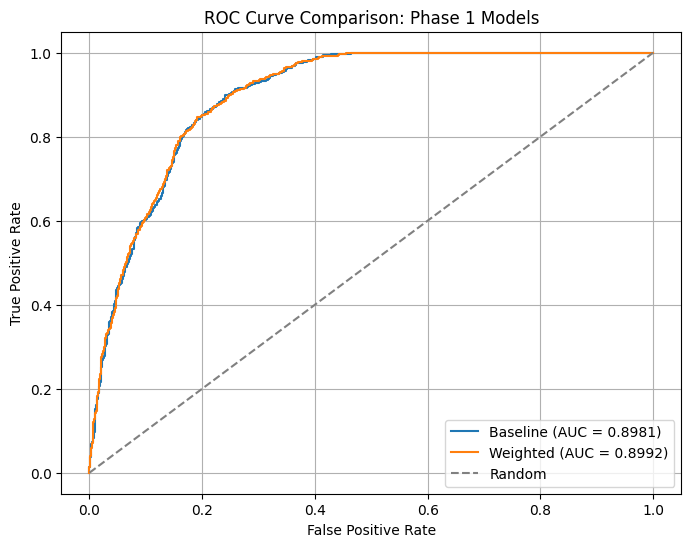

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
  precision_recall_fscore_support,
  accuracy_score,
  roc_auc_score,
  roc_curve
)

# Baseline probabilities/predictions
y_proba_baseline = phase1_model.predict_proba(X_test)[:, 1]
y_pred_baseline = (y_proba_baseline >= 0.5).astype(int)

# Weighted probabilities/predictions
y_proba_weighted = phase1_model_weighted.predict_proba(X_test)[:, 1]
y_pred_weighted = (y_proba_weighted >= 0.5).astype(int)

def collect_metrics(y_true, y_pred, y_proba, model_name):
  precision, recall, f1, support = precision_recall_fscore_support(
      y_true, y_pred, labels=[0, 1], zero_division=0
  )

  return {
      "model": model_name,
      "class_0_precision": precision[0],
      "class_0_recall": recall[0],
      "class_0_f1": f1[0],
      "class_0_support": support[0],
      "class_1_precision": precision[1],
      "class_1_recall": recall[1],
      "class_1_f1": f1[1],
      "class_1_support": support[1],
      "accuracy": accuracy_score(y_true, y_pred),
      "roc_auc": roc_auc_score(y_true, y_proba),
  }

metrics_df = pd.DataFrame([
  collect_metrics(y_test, y_pred_baseline, y_proba_baseline, "baseline"),
  collect_metrics(y_test, y_pred_weighted, y_proba_weighted, "weighted")
])

display(metrics_df)

# ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_baseline)
fpr_weighted, tpr_weighted, _ = roc_curve(y_test, y_proba_weighted)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {roc_auc_score(y_test, y_proba_baseline):.4f})")
plt.plot(fpr_weighted, tpr_weighted, label=f"Weighted (AUC = {roc_auc_score(y_test, y_proba_weighted):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Phase 1 Models")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
 raw_importance = pd.Series(
      phase1_model.feature_importances_,
      index=phase1_feature_cols
  ).sort_values(ascending=False)

  normalized_weights = raw_importance / raw_importance.sum()

  weights_df = normalized_weights.reset_index()
  weights_df.columns = ["feature", "normalized_weight"]

  weights_path = os.path.join(processed_dir, "phase1_feature_weights.csv")
  weights_df.to_csv(weights_path, index=False)

  print("Saved:", weights_path)

In [ ]:
  print("Acceptance checks")
  print("-" * 30)
  print("1. Positive pairs:", (labeled_pairs["label"] == 1).sum())
  print("2. Negative pairs:", (labeled_pairs["label"] == 0).sum())
  print("3. Total pairs:", len(labeled_pairs))
  print("4. Phase 1 AUC:", round(auc, 4))
  print("5. Top 5 weighted features:")
  display(weights_df.head(5))